## **Classwork: "The Attention Mechanism" — Fundamentals of Self-Attention**

**The Scenario**

You are a research engineer at "ContextAI". The team's RNN-based translation model struggles with long sentences — by the time it processes the final word, it has largely forgotten the first. Your tech lead proposes replacing the RNN with a **self-attention** mechanism that allows every token to directly attend to every other token in the sequence, regardless of distance. Your task is to understand why this works, derive the scaled dot-product attention formula by hand, and implement a full single-head self-attention layer from scratch.

## **Part 1:**

### **Question 1: Why Self-Attention Over RNNs?**

Self-attention and RNNs both process sequences, but they differ fundamentally in how information travels between distant positions. Which statement best describes the key advantage of self-attention for long sequences?

A) Self-attention uses more parameters than RNNs, so it has higher model capacity.

B) In self-attention, any two positions can interact directly in a single layer with a path length of 1, whereas in an RNN the signal from position 1 must pass through every intermediate hidden state to reach position $T$, creating a path length of $T-1$.

C) Self-attention applies the same operation at every time step in sequence, just like an RNN, but runs faster because it uses tanh instead of sigmoid.

D) Self-attention eliminates the need for any weight matrices by using raw dot products between input tokens.

Answer: (B)

Self-attention lets any token attend to any other token directly in one step (path length $1$), while an RNN must pass information through many intermediate steps (path length $T-1$). This makes self-attention much better at capturing long-range dependencies.


### **Question 2: The Role of Queries, Keys, and Values**

In scaled dot-product attention, each token's embedding is projected into three vectors: a **Query** $q$, a **Key** $k$, and a **Value** $v$. Using the analogy of a search engine:

- The **Query** is what you are searching *for*.
- The **Key** is what each document *advertises* about itself.
- The **Value** is what the document actually *contains*.

Given this, what does the attention weight $\alpha_{ij}$ between token $i$ (query) and token $j$ (key) represent?

A) The Euclidean distance between the embeddings of token $i$ and token $j$.

B) The proportion of token $j$'s value vector that will be mixed into token $i$'s output — determined by how well token $i$'s query matches token $j$'s key.

C) The gradient of the loss with respect to the $j$-th input token.

D) A binary mask indicating whether token $j$ is allowed to influence token $i$.

Answer: (B)

The attention weight $\alpha_{ij}$ tells how much token $j$'s **value** vector contributes to token $i$'s output after comparing $q_i$ with $k_j$.  
So it is a learned mixing coefficient (via softmax), not a distance, gradient, or binary mask.

### **Question 3: The Scaling Factor**

The attention score between query $q_i$ and key $k_j$ is computed as $\frac{q_i \cdot k_j}{\sqrt{d_k}}$, where $d_k$ is the dimension of the key vectors. Why is dividing by $\sqrt{d_k}$ necessary?

A) It ensures the attention weights sum to $d_k$ rather than 1, increasing model expressiveness.

B) Without scaling, dot products grow large in magnitude as $d_k$ increases (since they sum $d_k$ terms), pushing the softmax into regions of near-zero gradient and making training slow. Dividing by $\sqrt{d_k}$ keeps the variance of the scores roughly constant at 1.

C) It converts the dot product from cosine similarity into Euclidean distance.

D) It prevents the query and key matrices from learning the same weights during training.

Answer: (B)

Without scaling, the dot product $q_i \cdot k_j$ tends to grow with $d_k$, which can make softmax outputs overly peaked and gradients very small. Dividing by $\sqrt{d_k}$ keeps score magnitudes (and variance) controlled, leading to more stable training.lease answer here

## **Part 2:**

### **Question 4: Manual Attention Computation**

You have a sequence of **3 tokens**, each with embedding dimension $d_{model} = 2$ and key/query dimension $d_k = 2$. For simplicity the Query and Key projections are identity matrices, so $Q = K = X$:

$$X = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{bmatrix}$$

Use $\text{softmax}$ row-wise and recall $\sqrt{d_k} = \sqrt{2} \approx 1.414$.

**Step 1:** Compute the raw score matrix $S = Q K^\top$.

**Step 2:** Scale it: $S_{\text{scaled}} = S / \sqrt{d_k}$.

**Step 3:** Apply softmax row-wise to get the attention weight matrix $A$. You may use the approximations: $\text{softmax}([0.707, 0, 1.414]) \approx [0.26, 0.16, 0.58]$ and $\text{softmax}([0, 0.707, 0.707]) \approx [0.23, 0.385, 0.385]$.

**Step 4:** If the Value matrix $V = X$, write out (do not need to compute fully) what the output $O = AV$ would look like structurally — what is its shape and what does each row represent?

Please show your working here

- Step 1 — $S$:
    $$
    S = QK^\top = XX^\top
    =
    \begin{bmatrix}
    1 & 0\\
    0 & 1\\
    1 & 1
    \end{bmatrix}
    \begin{bmatrix}
    1 & 0 & 1\\
    0 & 1 & 1
    \end{bmatrix}
    =
    \begin{bmatrix}
    1 & 0 & 1\\
    0 & 1 & 1\\
    1 & 1 & 2
    \end{bmatrix}
    $$

- Step 2 — $S_{\text{scaled}}$:
    $$
    S_{\text{scaled}}=\frac{S}{\sqrt{2}}
    \approx
    \begin{bmatrix}
    0.707 & 0 & 0.707\\
    0 & 0.707 & 0.707\\
    0.707 & 0.707 & 1.414
    \end{bmatrix}
    $$

- Step 3 — $A$ (attention weights):
    Apply softmax row-wise:
    $$
    A \approx
    \begin{bmatrix}
    0.401 & 0.198 & 0.401\\
    0.23 & 0.385 & 0.385\\
    0.248 & 0.248 & 0.503
    \end{bmatrix}
    $$
    (Rows sum to 1.)

- Step 4 — Shape and meaning of $O$:
    $$
    O = AV,\quad V=X,\quad A\in\mathbb{R}^{3\times 3},\ V\in\mathbb{R}^{3\times 2}
    \Rightarrow O\in\mathbb{R}^{3\times 2}.
    $$
    Each row $o_i$ is a weighted sum of all three value vectors:
    $$
    o_i=\sum_{j=1}^{3} \alpha_{ij}v_j.
    $$
    So each token’s output is a context-mixed representation of all tokens.ease show your working here

## **Part 3: Coding Challenge — Self-Attention from Scratch**

You will implement the full scaled dot-product self-attention mechanism in NumPy, visualise the attention weight matrix, and observe how the output of each token is a weighted blend of all value vectors.

**Fill in the lines marked `## FILL IN`.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

np.random.seed(0)

# --- A toy 5-token sequence (e.g. "the cat sat on mat") ---
tokens    = ["the", "cat", "sat", "on", "mat"]
T         = len(tokens)   # sequence length
d_model   = 8             # embedding dimension
d_k       = 4             # query / key dimension
d_v       = 4             # value dimension

# Simulated token embeddings  (T x d_model)
X = np.random.randn(T, d_model)

# Projection weight matrices  (randomly initialised)
W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_v)

print("Shapes:")
print(f"  X    : {X.shape}   (T x d_model)")
print(f"  W_Q  : {W_Q.shape}  (d_model x d_k)")
print(f"  W_K  : {W_K.shape}  (d_model x d_k)")
print(f"  W_V  : {W_V.shape}  (d_model x d_v)")

Shapes:
  X    : (5, 8)   (T x d_model)
  W_Q  : (8, 4)  (d_model x d_k)
  W_K  : (8, 4)  (d_model x d_k)
  W_V  : (8, 4)  (d_model x d_v)


In [3]:
# ---------------------------------------------------------------
# Task A: Implement scaled dot-product self-attention
# ---------------------------------------------------------------

def softmax(x, axis=-1):
    """Numerically stable row-wise softmax."""
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


def self_attention(X, W_Q, W_K, W_V):
    """
    Scaled dot-product self-attention.

    Args:
        X   : (T, d_model)  — input token embeddings
        W_Q : (d_model, d_k)
        W_K : (d_model, d_k)
        W_V : (d_model, d_v)

    Returns:
        output   : (T, d_v)  — context-enriched token representations
        attn_w   : (T, T)    — attention weight matrix (rows sum to 1)
    """
    d_k = W_Q.shape[1]

    ## FILL IN Step 1: Project X into Q, K, V
    ## Q shape: (T, d_k),  K shape: (T, d_k),  V shape: (T, d_v)
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    ## FILL IN Step 2: Compute raw attention scores
    ## scores = Q @ K^T  then divide by sqrt(d_k)
    ## scores shape: (T, T)
    scores = (Q @ K.T) / np.sqrt(d_k)

    ## FILL IN Step 3: Apply softmax row-wise to get attention weights
    ## attn_w shape: (T, T)  — each row sums to 1
    attn_w = softmax(scores, axis=-1)

    ## FILL IN Step 4: Compute the output as weighted sum of V
    ## output = attn_w @ V
    ## output shape: (T, d_v)
    output = attn_w @ V

    return output, attn_w


output, attn_w = self_attention(X, W_Q, W_K, W_V)

print(f"Output shape      : {output.shape}   (T x d_v)")
print(f"Attention weights  : {attn_w.shape}  (T x T)")
print(f"\nRow sums of attn_w (should all be 1.0):")
print(attn_w.sum(axis=1).round(6))

Output shape      : (5, 4)   (T x d_v)
Attention weights  : (5, 5)  (T x T)

Row sums of attn_w (should all be 1.0):
[1. 1. 1. 1. 1.]


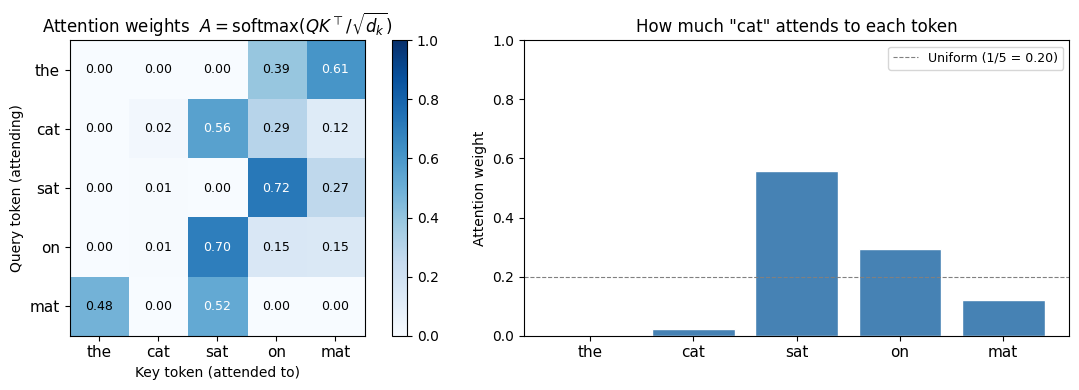

In [4]:
# ---------------------------------------------------------------
# Task B: Visualise the attention weight matrix
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: attention heatmap
im = axes[0].imshow(attn_w, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(T))
axes[0].set_yticks(range(T))
axes[0].set_xticklabels(tokens, fontsize=11)
axes[0].set_yticklabels(tokens, fontsize=11)
axes[0].set_xlabel('Key token (attended to)', fontsize=10)
axes[0].set_ylabel('Query token (attending)', fontsize=10)
axes[0].set_title('Attention weights  $A = \\mathrm{softmax}(QK^\\top / \\sqrt{d_k})$')
plt.colorbar(im, ax=axes[0])

# Annotate each cell with its weight value
for i in range(T):
    for j in range(T):
        axes[0].text(j, i, f"{attn_w[i, j]:.2f}",
                     ha='center', va='center', fontsize=9,
                     color='white' if attn_w[i, j] > 0.5 else 'black')

# Plot 2: per-token attention distribution (bar chart for one query token)
query_idx = 1  # "cat" is attending
axes[1].bar(range(T), attn_w[query_idx], color='steelblue', edgecolor='white')
axes[1].set_xticks(range(T))
axes[1].set_xticklabels(tokens, fontsize=11)
axes[1].set_ylabel('Attention weight')
axes[1].set_title(f'How much "{tokens[query_idx]}" attends to each token')
axes[1].set_ylim(0, 1)
axes[1].axhline(1/T, color='gray', linestyle='--', linewidth=0.8,
                label=f'Uniform (1/{T} = {1/T:.2f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

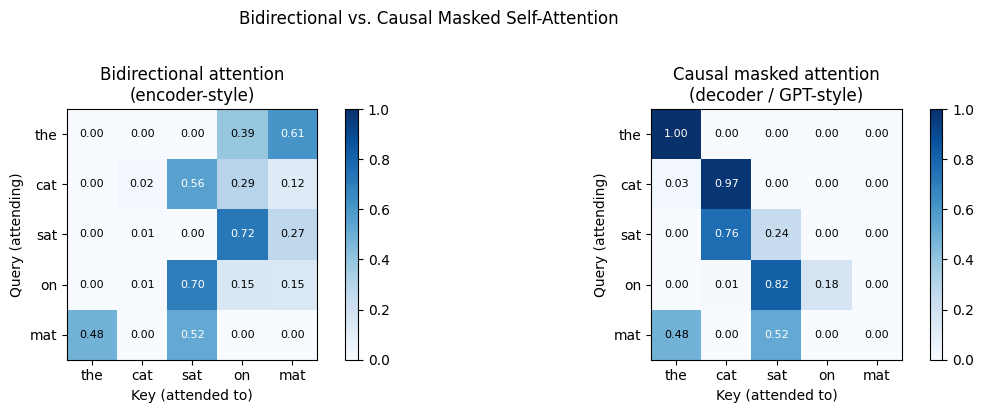

Causal attention weight matrix (upper triangle should be ~0):
[[1.    0.    0.    0.    0.   ]
 [0.027 0.973 0.    0.    0.   ]
 [0.    0.765 0.235 0.    0.   ]
 [0.    0.008 0.816 0.175 0.   ]
 [0.479 0.    0.521 0.    0.   ]]


In [5]:
# ---------------------------------------------------------------
# Task C: Causal (autoregressive) masking
#
# In a language model, token t should only attend to tokens
# at positions <= t (no peeking at the future).
# This is enforced by adding -infinity to all future positions
# before softmax, so those positions get attention weight ~0.
# ---------------------------------------------------------------

def causal_self_attention(X, W_Q, W_K, W_V):
    """
    Masked (causal) self-attention — used in decoder-only LMs.
    Token at position t can only attend to positions 0..t.
    """
    d_k = W_Q.shape[1]
    T   = X.shape[0]

    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    scores = (Q @ K.T) / np.sqrt(d_k)

    ## FILL IN: build a causal mask and apply it
    ## The mask should be a (T, T) boolean matrix where
    ## mask[i, j] = True  if j > i  (future token — should be masked)
    ## Set masked positions to -1e9 before softmax.
    ## Hint: np.triu(np.ones((T, T)), k=1).astype(bool)
    mask = np.triu(np.ones((T, T)), k=1).astype(bool)
    scores[mask] = -1e9

    attn_w = softmax(scores)
    output = attn_w @ V
    return output, attn_w


output_causal, attn_w_causal = causal_self_attention(X, W_Q, W_K, W_V)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (w, title) in zip(axes, [
        (attn_w,        'Bidirectional attention\n(encoder-style)'),
        (attn_w_causal, 'Causal masked attention\n(decoder / GPT-style)')]):
    im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel('Key (attended to)')
    ax.set_ylabel('Query (attending)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(T):
        for j in range(T):
            ax.text(j, i, f"{w[i,j]:.2f}",
                    ha='center', va='center', fontsize=8,
                    color='white' if w[i, j] > 0.5 else 'black')

plt.suptitle('Bidirectional vs. Causal Masked Self-Attention', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Causal attention weight matrix (upper triangle should be ~0):")
print(attn_w_causal.round(3))

Write your observations:

> **Task A/B:**
> 1. Each row of the attention weight matrix sums to 1.0. In plain English, what does this mean about how the output for each token is constructed from the values?
> 2. Look at the bar chart for the token `"cat"`. Is its attention evenly spread across all tokens, or concentrated? What might this imply about what "cat" is attending to, given that the weights were randomly initialised?
>
> **Task C:**
> 3. In the causal attention heatmap, what pattern do you observe in the upper triangle? Why is this necessary for autoregressive text generation?
> 4. BERT uses bidirectional (unmasked) attention; GPT uses causal (masked) attention. Given what you have implemented, which architecture would you use for (a) a sentiment classifier and (b) a text generation model? Justify your answer.

...


1. Since each row of $A$ sums to 1, each token’s output is a **convex combination** (weighted average) of all value vectors.  
    In other words, for token $i$, $o_i=\sum_j \alpha_{ij}v_j$, and the weights $\alpha_{ij}$ form a probability distribution over tokens.

2. For `"cat"` (row index 1), attention is **not evenly spread**. It is concentrated mostly on `"sat"` ($\approx 0.558$) and `"on"` ($\approx 0.294$), with much smaller weight on `"the"` and `"cat"` itself.  
    With random initialization, this reflects accidental high dot-product similarity in projected $Q/K$ space, not learned linguistic meaning yet.

3. In the causal heatmap, the **upper triangle is zero (or ~0)**, meaning token $t$ cannot attend to positions $>t$.  
    This is necessary for autoregressive generation so the model does not leak future tokens during training/inference (maintains next-token prediction causality).

4. Architecture choice:
    - **(a) Sentiment classifier:** use **BERT-style bidirectional attention**, because classification benefits from seeing full left and right context.
    - **(b) Text generation model:** use **GPT-style causal attention**, because generation must predict token-by-token without access to future tokens.

## **The Effect of Temperature on Attention Sharpness**

In practice, a **temperature** parameter $\tau$ is sometimes used to control how peaked or diffuse the attention distribution is:
$$\text{Attention} = \text{softmax}\!\left(\frac{QK^\top}{\tau}\right)$$

Note that the standard formula uses $\tau = \sqrt{d_k}$.

Complete the function below to compute attention at three different temperatures and plot how the weight distribution for token `"cat"` changes.

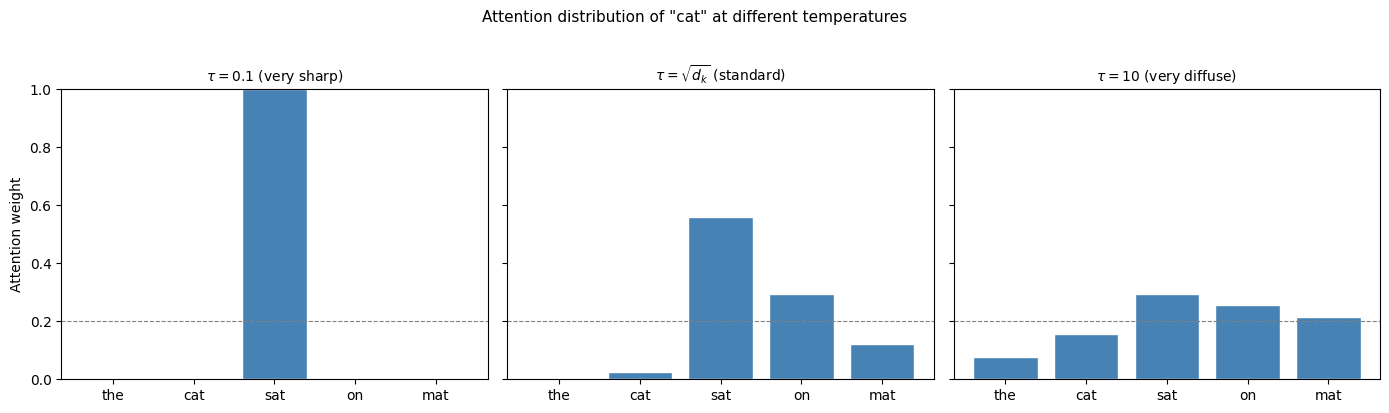

In [6]:
def attention_with_temperature(X, W_Q, W_K, W_V, temperature):
    """
    Self-attention with a custom temperature tau.
    Divides the raw scores by `temperature` before softmax.
    """
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    ## FILL IN: compute scores divided by temperature (not sqrt(d_k)),
    ## apply softmax, compute output
    scores = (Q @ K.T) / temperature
    attn_w = softmax(scores, axis=-1)
    output = attn_w @ V
    return output, attn_w


temperatures = [0.1, np.sqrt(d_k), 10.0]  # sharp, standard, diffuse
labels       = [r'$\tau=0.1$ (very sharp)', r'$\tau=\sqrt{d_k}$ (standard)', r'$\tau=10$ (very diffuse)']
query_idx    = 1  # "cat"

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, tau, label in zip(axes, temperatures, labels):
    _, w = attention_with_temperature(X, W_Q, W_K, W_V, tau)
    ax.bar(range(T), w[query_idx], color='steelblue', edgecolor='white')
    ax.set_xticks(range(T))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=10)
    ax.axhline(1/T, color='gray', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Attention weight' if ax == axes[0] else '')

plt.suptitle(f'Attention distribution of "{tokens[query_idx]}" at different temperatures',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

**Reflection:** What happens to the attention distribution as temperature approaches 0? What about as it approaches infinity? In which direction does lower temperature push the model, and when might you want a more diffuse attention distribution during inference?

...

As temperature $\tau \to 0^+$, the softmax becomes extremely sharp: attention for each query collapses to (almost) a one-hot distribution on the largest score (argmax key).  
As $\tau \to \infty$, score differences are washed out and attention approaches a uniform distribution ($\approx 1/T$ per token).

So, **lower temperature pushes attention toward harder, more selective focus** (high confidence, low entropy).  
A **more diffuse** distribution can be useful when uncertainty is high, when multiple tokens may be relevant, or when smoother/less brittle behavior is preferred during inference (e.g., noisy or ambiguous context).